# Day 5: Exploratory Data Analysis.

### TOP 3 Performing Products

In [22]:
import pandas as pd
df = pd.read_csv("../data/products.csv")
top_3 = df.groupby('productID')['Sales'].sum().nlargest(3)
top_3.to_csv("../data/top3.csv")
print(top_3)

productID
3    2000
1    1850
4     450
Name: Sales, dtype: int64


### Comparison of Top 3 Performing Products

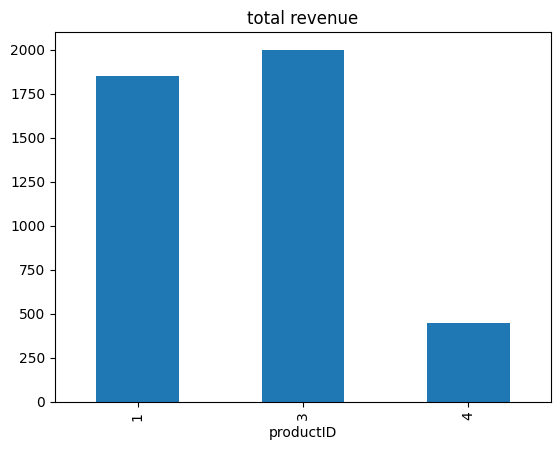

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# LOAD DATA
df = pd.read_csv("../data/top3.csv")

# BAR CHART
df.groupby('productID')['Sales'].sum().plot(kind='bar')
plt.title("total revenue")
plt.show()

### Corelation of the Top Performers

productID       1      2      3      4      5
Date                                         
2024-01-01  500.0    NaN    NaN    NaN    NaN
2024-01-02  700.0    NaN    NaN    NaN    NaN
2024-01-03    NaN    NaN  300.0    NaN    NaN
2024-01-04    NaN    NaN  900.0    NaN    NaN
2024-01-05    NaN    NaN    NaN    NaN  200.0
2024-01-06    NaN    NaN    NaN  450.0    NaN
2024-01-07    NaN    NaN  800.0    NaN    NaN
2024-01-08  650.0    NaN    NaN    NaN    NaN
2024-01-09    NaN  400.0    NaN    NaN    NaN
2024-01-10    NaN    NaN    NaN    NaN  220.0
Correlation Matrix Shape: (5, 5)
Products being correlated: [1, 2, 3, 4, 5]

Correlation Matrix:
productID         1         2         3         4         5
productID                                                  
1          1.000000 -0.215317 -0.382627 -0.215317 -0.322518
2         -0.215317  1.000000 -0.197450 -0.111111 -0.166431
3         -0.382627 -0.197450  1.000000 -0.197450 -0.295756
4         -0.215317 -0.111111 -0.197450  1.000000 -

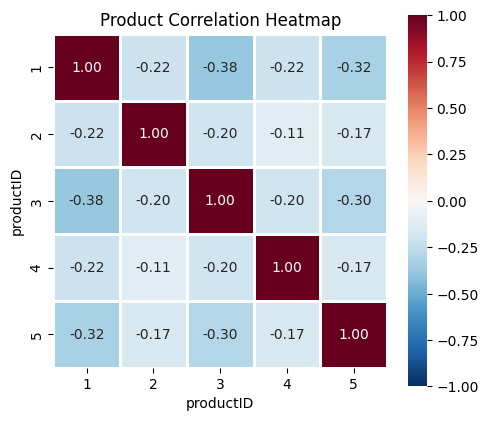

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/sales.csv")

# Pivot to get products as columns and dates as rows
# This creates a matrix where each column is a product and each row is a date
pivot_df = df.pivot_table(index='Date', columns='productID', values='Sales')
print(pivot_df)

# Fill any NaN values with 0 (in case some products don't have sales on certain dates)
pivot_df = pivot_df.fillna(0)

# Calculate correlation between products (correlate the columns)
correlation_matrix = pivot_df.corr()

print("Correlation Matrix Shape:", correlation_matrix.shape)
print("Products being correlated:", correlation_matrix.columns.tolist())
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Create a Heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f',
            vmin=-1, vmax=1)
plt.title("Product Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation vs Causation: The Analysis
#### Answer: 
No, a correlation of 0.85 does NOT mean Product A causes Product B to sell.
#### Why?
Looking at our Product Correlation Heatmap, we can see that productID 1 and 2 have a -0.22 correlation (negative relationship). This means:

Correlation measures relationship, not causation Just because two variables move together doesn't mean one causes the other.
Example from our data: ProductID 1 and 2 are negatively correlated (-0.22), but the product ID number doesn't cause low or high sales. The ID is just a label. The actual cause of sales could be:

- Product quality
- Marketing effort
- Customer demand
- Pricing
- Market conditions


#### Real-world example: 
Ice cream sales and drowning deaths are highly correlated in summer, but ice cream doesn't cause drowning. The real cause? Warm weather drives both.

#### Conclusion: 
Correlation shows a statistical pattern. Causation requires evidence that one thing directly causes another. To prove causation, you'd need:

Controlled experiments
Logical mechanism
Temporal order (cause happens before effect)
Elimination of other explanations